# Classical Baselines: ETS and SARIMA

Both models are fast and share the same conceptual framing — decompose the series into trend, seasonality, and error. Running them in a single notebook makes the side-by-side comparison direct.

**Outline**
1. Load train/test data
2. Build month-dummy exogenous matrix
3. ETS — multiplicative vs additive seasonality comparison
4. SARIMA — auto_arima with monthly exog, residual diagnostics
5. Metrics: RMSE, MAE, MAPE
6. Side-by-side forecast plot and export

---

## Step 0: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error
import pmdarima

## Step 1: Load Data

In [2]:
train = pd.read_csv('../data/daily_train.csv', index_col='datetime', parse_dates=True)
test  = pd.read_csv('../data/daily_test.csv',  index_col='datetime', parse_dates=True)

train_series = train['power']
test_series  = test['power']

print(f"Train: {train_series.index.min().date()} → {train_series.index.max().date()} ({len(train_series)} obs)")
print(f"Test:  {test_series.index.min().date()}  → {test_series.index.max().date()} ({len(test_series)} obs)")

Train: 2006-12-16 → 2009-11-30 (1081 obs)
Test:  2009-12-01  → 2010-11-26 (361 obs)


## Step 2: Month Dummy Exogenous Matrix

Month dummies are the practical way to inject annual seasonality into SARIMA on daily data. The alternative — `m=365` in `auto_arima` — is computationally infeasible: the seasonal search space over a 365-lag grid makes the fit run for hours and typically produces unstable estimates. The approach here uses `m=7` for the ARIMA seasonal component (weekly cycles) and month dummies as exogenous regressors to capture the annual pattern.

All 12 months are kept (no `drop_first`) because SARIMA has no intercept by default; dropping one column would leave the baseline month unrepresented.

In [3]:
def build_month_dummies(index):
    dummies = pd.get_dummies(index.month, prefix='m', drop_first=False)
    dummies.index = index
    return dummies.astype(float)

train_exog = build_month_dummies(train_series.index)
test_exog  = build_month_dummies(test_series.index)

# align columns in case test set doesn't cover every month
test_exog = test_exog.reindex(columns=train_exog.columns, fill_value=0.0)

train_exog.head(3)

,m_1,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
datetime,,,,,,,,,,,,
2006-12-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2006-12-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2006-12-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Step 3: ETS

### 3.1 Multiplicative vs Additive Seasonality

Multiplicative seasonality scales the seasonal component proportionally to the level — appropriate when winter variance is larger *relative to* the series level, not just additively larger. Energy consumption has this property: high-usage winter months show wider swings than low-usage summer months. Fit both and compare AIC.

In [4]:
ets_mul = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal='mul',
    seasonal_periods=7
).fit(optimized=True)

ets_add = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit(optimized=True)

print(f"{'Model':<28} {'AIC':>10}")
print("-" * 39)
print(f"{'ETS(A,A,A) — additive seas':<28} {ets_add.aic:>10.2f}")
print(f"{'ETS(A,A,M) — multiplicative seas':<28} {ets_mul.aic:>10.2f}")
print(f"\nΔAIC (add − mul): {ets_add.aic - ets_mul.aic:+.2f}")
print("\nUsing multiplicative for downstream forecasting.")

c:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\brody\anaconda3\envs\energy-forecast\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Model                               AIC
---------------------------------------
ETS(A,A,A) — additive seas     -2558.27
ETS(A,A,M) — multiplicative seas   -2580.91

ΔAIC (add − mul): +22.64

Using multiplicative for downstream forecasting.


### 3.2 ETS Forecast

In [5]:
h = len(test_series)
ets_forecast = ets_mul.forecast(h)
ets_forecast.index = test_series.index

## Step 4: SARIMA

### 4.1 Model Selection via auto_arima

In [6]:
sarima_model = pmdarima.auto_arima(
    train_series,
    X=train_exog.values,
    seasonal=True,
    m=7,              # weekly seasonal component
    d=None,           # ADF-selected integration order
    D=None,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True,
)

print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=453.948, Time=2.16 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=766.587, Time=0.29 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=560.606, Time=0.74 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=577.548, Time=0.76 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=764.587, Time=0.34 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=561.923, Time=2.40 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=550.144, Time=1.83 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=459.155, Time=3.27 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=461.258, Time=3.64 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=604.500, Time=1.20 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=552.787, Time=3.24 sec
 ARIMA(2,0,2)(2,0,0)[7] intercept   : AIC=534.906, Time=3.00 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=457.821, Time=4.01 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=457.454, Time=2.03 sec
 ARIMA(2,0,1)(1,0,1)[7] intercept   : AIC=482.5

### 4.2 Do Month Dummies Add Signal?

Refit auto_arima without exogenous regressors and compare AIC. A meaningful delta (typically > 10) confirms the month dummies are capturing annual variance that the ARIMA terms alone cannot.

In [7]:
sarima_no_exog = pmdarima.auto_arima(
    train_series,
    seasonal=True,
    m=7,
    d=None,
    D=None,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=False,
)

aic_with    = sarima_model.aic()
aic_without = sarima_no_exog.aic()
delta       = aic_without - aic_with

print(f"{'Model':<35} {'AIC':>10}")
print("-" * 46)
print(f"{'SARIMA + month dummies':<35} {aic_with:>10.2f}")
print(f"{'SARIMA (no exog)':<35} {aic_without:>10.2f}")
print(f"\nΔAIC (no exog − with dummies): {delta:+.2f}")
print()
if delta > 10:
    print("Month dummies provide meaningful signal — keeping them.")
elif delta > 2:
    print("Month dummies provide modest improvement — worth keeping but not decisive.")
else:
    print("Month dummies add little signal — the ARIMA terms may already account for annual structure.")

Model                                      AIC
----------------------------------------------
SARIMA + month dummies                  439.43
SARIMA (no exog)                        463.30

ΔAIC (no exog − with dummies): +23.88

Month dummies provide meaningful signal — keeping them.


### 4.3 Residual Diagnostics

The standard 4-panel diagnostics check for normality and remaining autocorrelation. The annual ACF check below is the key honest-accounting step: if structure remains at lag ~365, the model has not captured the full seasonal pattern and month dummies alone were insufficient.

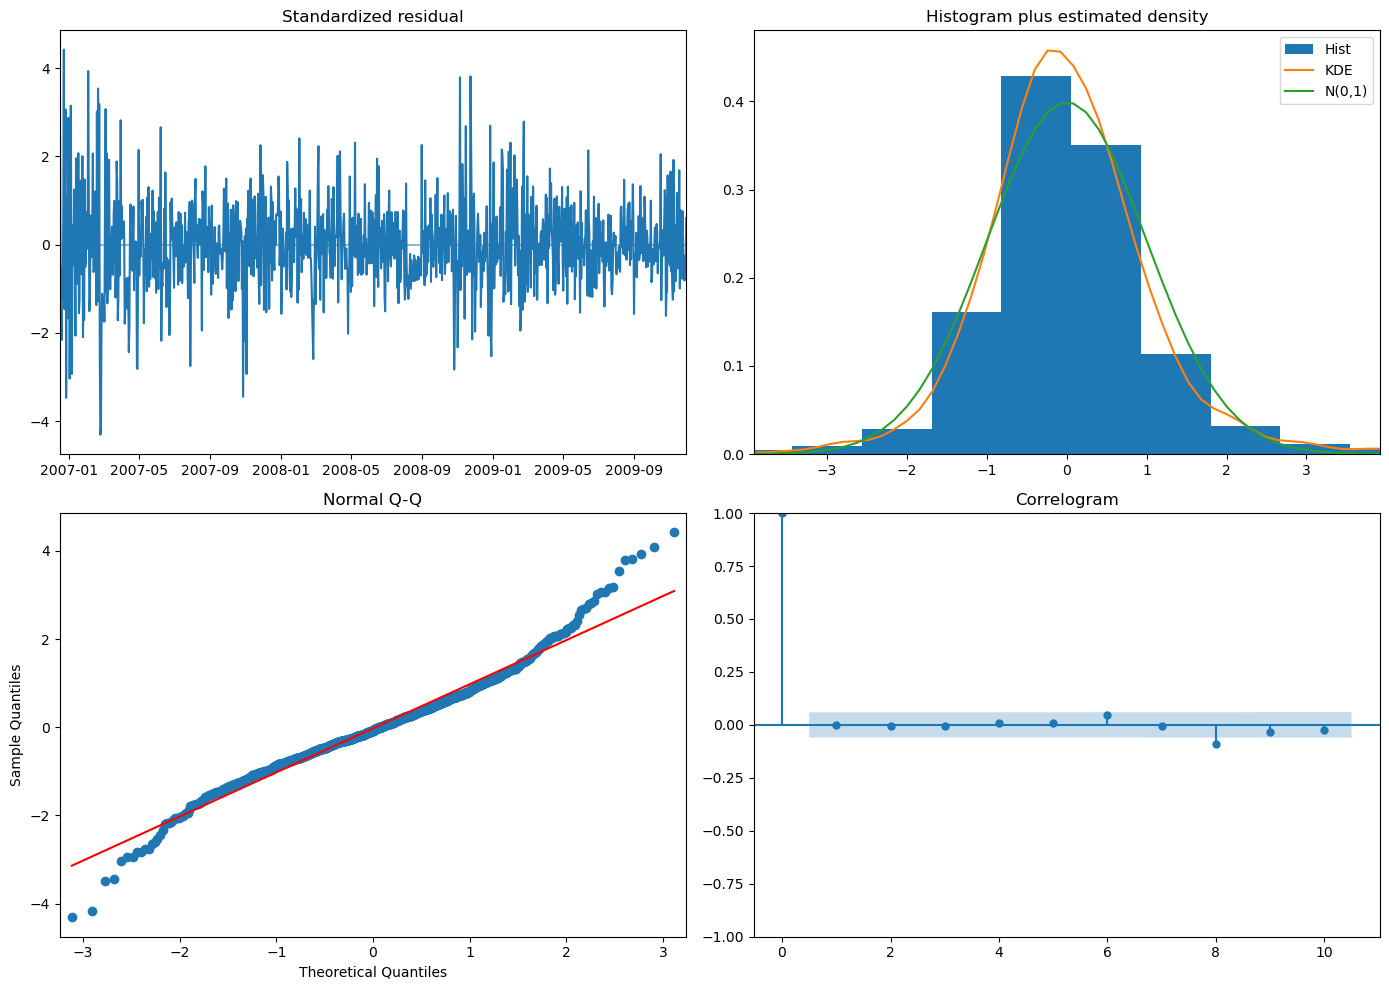

In [8]:
sarima_model.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

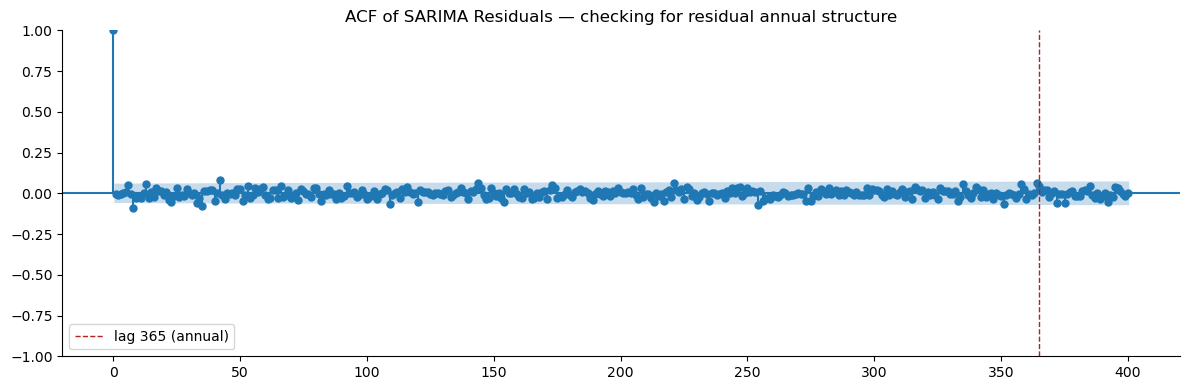

In [9]:
resid = pd.Series(sarima_model.resid(), index=train_series.index)

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(resid, lags=min(400, len(resid) - 1), ax=ax, alpha=0.05)
ax.axvline(x=365, color='firebrick', linestyle='--', linewidth=1.0, label='lag 365 (annual)')
ax.legend()
ax.set_title('ACF of SARIMA Residuals — checking for residual annual structure')
sns.despine()
plt.tight_layout()
plt.show()

**Residual notes** *(fill in after running)*

- If the ACF shows significant spikes near lag 365: the month dummies captured the average monthly level but not intra-annual variance — Fourier terms or a longer training window may help.
- If weekly lags (7, 14, 21…) still show spikes: `m=7` seasonal order selected by auto_arima is underfitting short-cycle patterns.
- Ljung-Box p-values below 0.05 in the diagnostics panel indicate autocorrelation in residuals — the model order should be revisited.

### 4.4 SARIMA Forecast

In [10]:
sarima_preds, conf_int = sarima_model.predict(
    n_periods=h,
    X=test_exog.values,
    return_conf_int=True,
)

sarima_forecast = pd.Series(sarima_preds, index=test_series.index)
conf_int_df = pd.DataFrame(conf_int, index=test_series.index, columns=['lower', 'upper'])

## Step 5: Metrics

In [11]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics = pd.DataFrame({
    'RMSE': [rmse(test_series, ets_forecast),            rmse(test_series, sarima_forecast)],
    'MAE':  [mean_absolute_error(test_series, ets_forecast), mean_absolute_error(test_series, sarima_forecast)],
    'MAPE': [mape(test_series, ets_forecast),            mape(test_series, sarima_forecast)],
}, index=['ETS', 'SARIMA']).round(4)

print(metrics.to_string())
metrics.to_csv('../outputs/classical_metrics.csv')
print("\nSaved → ../outputs/classical_metrics.csv")

          RMSE     MAE     MAPE
ETS     0.3536  0.2784  29.1003
SARIMA  0.2699  0.1985  21.7144

Saved → ../outputs/classical_metrics.csv


## Step 6: Side-by-Side Forecast Plot

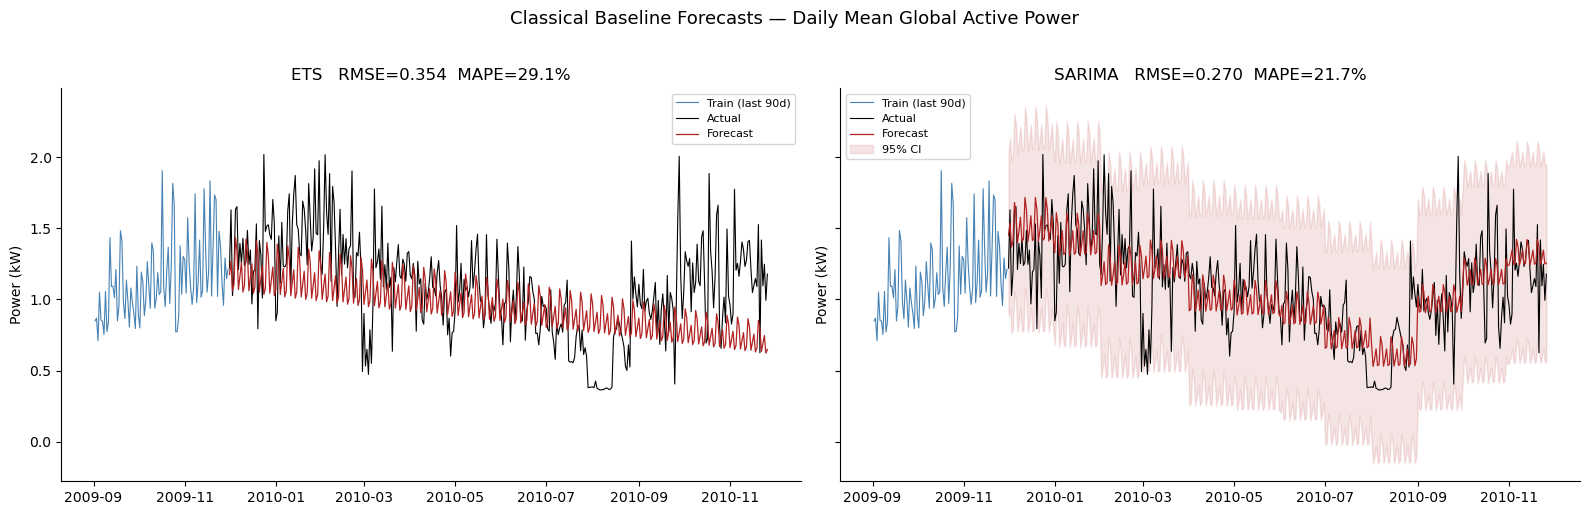

Saved → ../outputs/classical_forecasts.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (label, forecast) in zip(axes, [('ETS', ets_forecast), ('SARIMA', sarima_forecast)]):
    ax.plot(train_series.iloc[-90:], color='steelblue', linewidth=0.8, label='Train (last 90d)')
    ax.plot(test_series,             color='black',     linewidth=0.8, label='Actual')
    ax.plot(forecast,                color='firebrick', linewidth=0.9, label='Forecast')

    if label == 'SARIMA':
        ax.fill_between(
            conf_int_df.index,
            conf_int_df['lower'],
            conf_int_df['upper'],
            color='firebrick', alpha=0.12, label='95% CI'
        )

    rmse_val = rmse(test_series, forecast)
    mape_val = mape(test_series, forecast)
    ax.set_title(f'{label}   RMSE={rmse_val:.3f}  MAPE={mape_val:.1f}%')
    ax.set_ylabel('Power (kW)')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Classical Baseline Forecasts — Daily Mean Global Active Power', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/classical_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/classical_forecasts.png")